## ***Data loading***

In [37]:
# Libraries

#basics
import numpy as np
import pandas as pd
import os

#graphs
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

#Regression
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM

#CV
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score


In [38]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [39]:
all_pred_GPT5 = pd.read_csv('/content/drive/MyDrive/DATA SCIENCE 23 24/THESIS/SIT /all_pred_GPT5.csv')
all_pred_GAMMA = pd.read_csv('/content/drive/MyDrive/DATA SCIENCE 23 24/THESIS/SIT /all_pred_GAMMA.csv')
all_pred_GEMINI = pd.read_csv('/content/drive/MyDrive/DATA SCIENCE 23 24/THESIS/SIT /all_pred_GEMINI.csv')
all_pred_GEMMA = pd.read_csv('/content/drive/MyDrive/DATA SCIENCE 23 24/THESIS/SIT /all_pred_GEMMA.csv')
all_pred_LLaMA = pd.read_csv('/content/drive/MyDrive/DATA SCIENCE 23 24/THESIS/SIT /all_pred_LLaMA.csv')
all_pred_instruct4 = pd.read_csv('/content/drive/MyDrive/DATA SCIENCE 23 24/THESIS/SIT /all_pred_instruct4.csv')

In [40]:
#making one dataset out of the 6 ones I have from the different models I used to create the haiku

all_pred_GPT5['Model'] = 'GPT5'
all_pred_GAMMA['Model'] = 'GAMMA'
all_pred_GEMINI['Model'] = 'GEMINI'
all_pred_GEMMA['Model'] = 'GEMMA'
all_pred_LLaMA['Model'] = 'LLaMA'
all_pred_instruct4['Model'] = 'instruct4'

all_pred = pd.concat([all_pred_GPT5, all_pred_GAMMA, all_pred_GEMINI, all_pred_GEMMA, all_pred_LLaMA, all_pred_instruct4], ignore_index=True)

In [41]:
col = all_pred.pop('Model')
all_pred.insert(1, 'Model', col)

all_pred.head(3)

,Dataset,Model,Respondent,Haiku,Truth,Guess,Correct
0,AW,GPT5,0,1,AI,AI,1
1,AW,GPT5,0,2,Human,AI,0
2,AW,GPT5,0,3,Human,AI,0


#### **Heatmap**

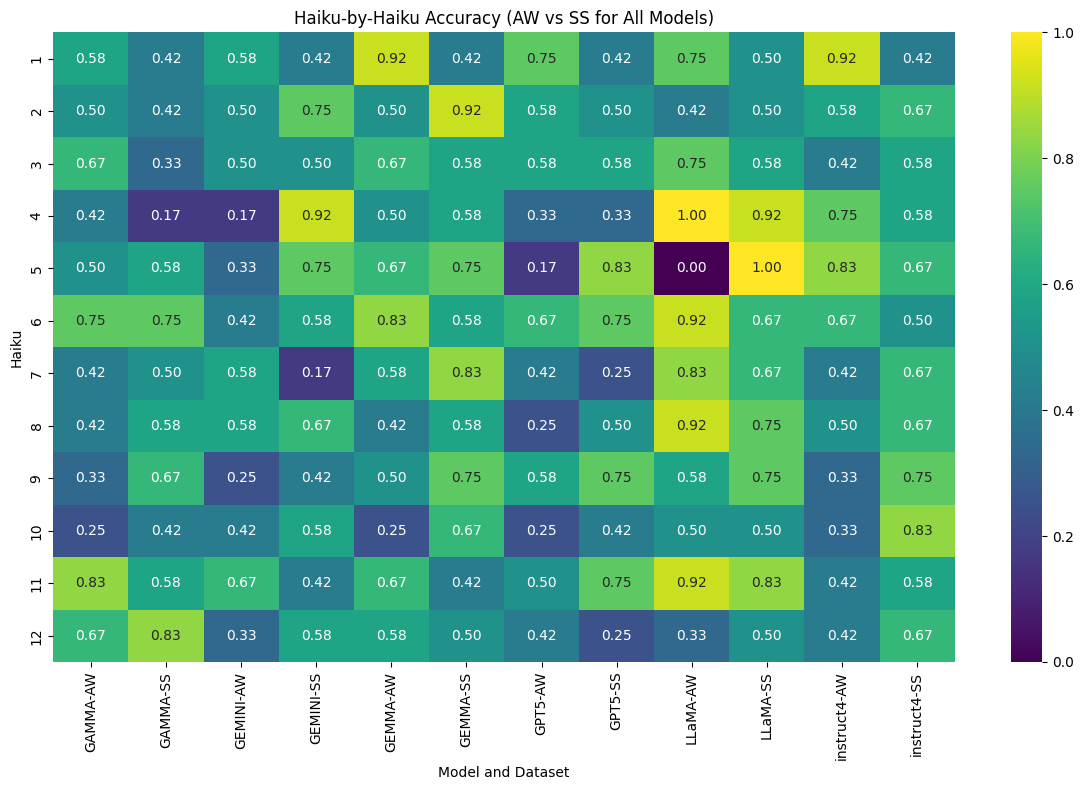

In [42]:
#to compute the accuracy
haiku_acc = (
    all_pred
    .groupby(["Model", "Dataset", "Haiku"])
    ["Correct"]
    .mean()
    .reset_index()
)

# Heatmap
# 'Haiku' as rows, 'Model' and 'Dataset' as columns, and 'Correct' (accuracy) as values
heat = (
    haiku_acc
    .pivot_table(index='Haiku', columns=['Model', 'Dataset'], values='Correct')
    .sort_index(axis=1)  # Optional: sort columns if necessary
)


plt.figure(figsize=(12, 8))


sns.heatmap(
    heat,
    annot=True,  # Annotate with the accuracy values
    fmt=".2f",
    cmap="viridis",
    vmin=0, vmax=1
)


plt.title("Haiku-by-Haiku Accuracy (AW vs SS for All Models)")
plt.ylabel("Haiku")
plt.xlabel("Model and Dataset")

plt.tight_layout()

plt.show()

#### **Impression ratings boxplot**

In [43]:
long_all_GPT5 = pd.read_csv('/content/drive/MyDrive/DATA SCIENCE 23 24/THESIS/SIT /long_all_GPT5.csv')
long_all_GAMMA = pd.read_csv('/content/drive/MyDrive/DATA SCIENCE 23 24/THESIS/SIT /long_all_GAMMA.csv')
long_all_GEMINI = pd.read_csv('/content/drive/MyDrive/DATA SCIENCE 23 24/THESIS/SIT /long_all_GEMINI.csv')
long_all_GEMMA = pd.read_csv('/content/drive/MyDrive/DATA SCIENCE 23 24/THESIS/SIT /long_all_GEMMA.csv')
long_all_LLaMA = pd.read_csv('/content/drive/MyDrive/DATA SCIENCE 23 24/THESIS/SIT /long_all_LLaMA.csv')
long_all_instruct4 = pd.read_csv('/content/drive/MyDrive/DATA SCIENCE 23 24/THESIS/SIT /long_all_instruct4.csv')

In [44]:
#making one dataset out of the 6 ones I have from the different models I used to create the haiku

long_all_GPT5['Model'] = 'GPT5'
long_all_GAMMA['Model'] = 'GAMMA'
long_all_GEMINI['Model'] = 'GEMINI'
long_all_GEMMA['Model'] = 'GEMMA'
long_all_LLaMA['Model'] = 'LLaMA'
long_all_instruct4['Model'] = 'instruct4'

long_all = pd.concat([long_all_GPT5, long_all_GAMMA, long_all_GEMINI, long_all_GEMMA, long_all_LLaMA, long_all_instruct4], ignore_index=True)

In [45]:
long_all.head(5)

,Dataset,Respondent,Haiku,Truth,Guess,Confidence,Fluency,Haiku_Wording,Poeticness,Coherence,Understandability,Favourability,Unexpectedness,Model
0,AW,0,1,AI,AI,4.0,4.0,4.0,2.0,3.0,5.0,2.0,1.0,GPT5
1,AW,0,2,Human,AI,5.0,1.0,1.0,2.0,2.0,1.0,1.0,3.0,GPT5
2,AW,0,3,Human,AI,4.0,2.0,1.0,2.0,3.0,2.0,2.0,4.0,GPT5
3,AW,0,4,AI,Human,5.0,5.0,5.0,5.0,5.0,5.0,5.0,3.0,GPT5
4,AW,0,5,AI,Human,4.0,5.0,5.0,5.0,5.0,5.0,5.0,4.0,GPT5


In [46]:
# Impression-score bags analysis (S_ai, S_human, T_ai, T_human)

def build_long_truth_guess_ratings(df, true_sources, dataset_label, impression_metrics):
    """
    Long-format dataframe with one row per (respondent, haiku):
    Dataset | Respondent | Haiku | Truth | Guess | + impression metrics
    """
    df = df.copy()

    repl = {
        "AI / Machine": "AI",
        "AI/ Machine": "AI",
        "AI /machine": "AI",
        "AI/machine": "AI",
        "AI": "AI",
        "ai": "AI",
        "Human": "Human",
        "human": "Human",
        "Human ": "Human",
        " AI": "AI",
    }

    rows = []
    for resp_id, row in df.iterrows():
        for h in range(1, 13):
            guess_col = f"Haiku{h}_Source_Judgment"
            if guess_col not in df.columns:
                continue

            guess = row.get(guess_col, np.nan)
            if isinstance(guess, str):
                guess = guess.strip()
            guess = repl.get(guess, guess)

            truth = true_sources.get(h, None)
            if pd.isna(guess) or truth is None:
                continue
            if guess not in {"AI", "Human"}:
                continue

            r = {
                "Dataset": dataset_label,
                "Respondent": resp_id,
                "Haiku": h,
                "Truth": truth,
                "Guess": guess,
            }

            for m in impression_metrics:
                r[m] = row.get(f"Haiku{h}_{m}", np.nan)

            rows.append(r)

    return pd.DataFrame(rows)


def compute_ST_bags_summary(long_df, impression_metrics):
    """
    Returns summary stats for each metric and dataset:
      S_ai, S_human, T_ai, T_human with N/Mean/SD/Median
    """
    out = []

    for ds, d in long_df.groupby("Dataset"):
        for m in impression_metrics:
            S_ai = d.loc[d["Truth"] == "AI", m].dropna()
            S_hu = d.loc[d["Truth"] == "Human", m].dropna()
            T_ai = d.loc[d["Guess"] == "AI", m].dropna()
            T_hu = d.loc[d["Guess"] == "Human", m].dropna()

            def add(set_name, x):
                out.append({
                    "Dataset": ds,
                    "Metric": m,
                    "Set": set_name,
                    "N": int(len(x)),
                    "Mean": float(x.mean()) if len(x) else np.nan,
                    "SD": float(x.std(ddof=1)) if len(x) > 1 else np.nan,
                    "Median": float(x.median()) if len(x) else np.nan,
                })

            add("S_ai (true AI)", S_ai)
            add("S_human (true Human)", S_hu)
            add("T_ai (judged AI)", T_ai)
            add("T_human (judged Human)", T_hu)

    return pd.DataFrame(out)

impression_metrics = [
    "Fluency",
    "Haiku_Wording",
    "Poeticness",
    "Coherence",
    "Understandability",
    "Favourability",
    "Unexpectedness"
]

In [47]:
print("Rows per Dataset:\n", long_all["Dataset"].value_counts(dropna=False))

Rows per Dataset:
 Dataset
AW    864
SS    864
Name: count, dtype: int64


/tmp/ipython-input-839380552.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


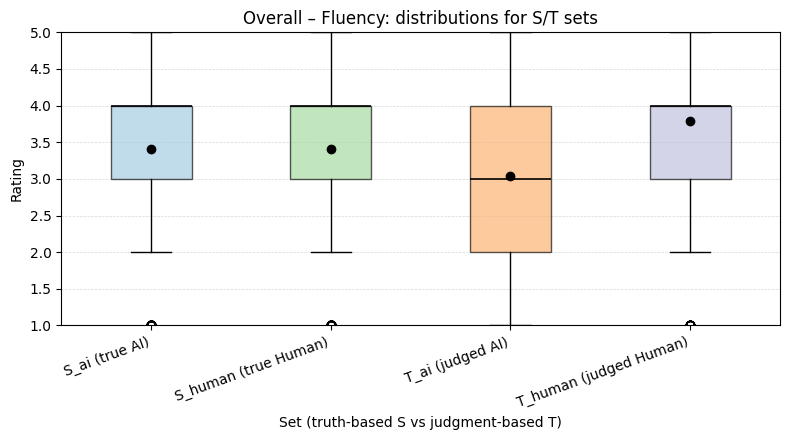

/tmp/ipython-input-839380552.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


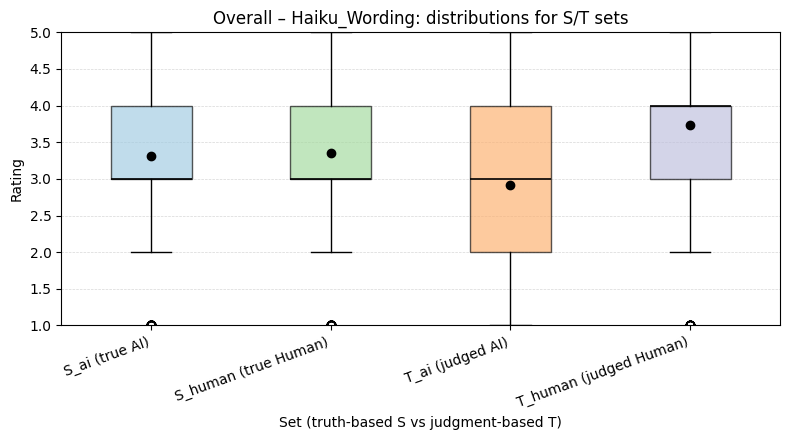

/tmp/ipython-input-839380552.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


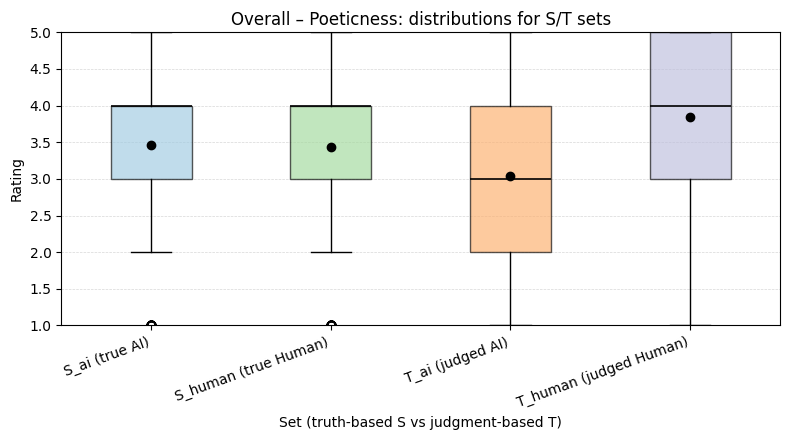

/tmp/ipython-input-839380552.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


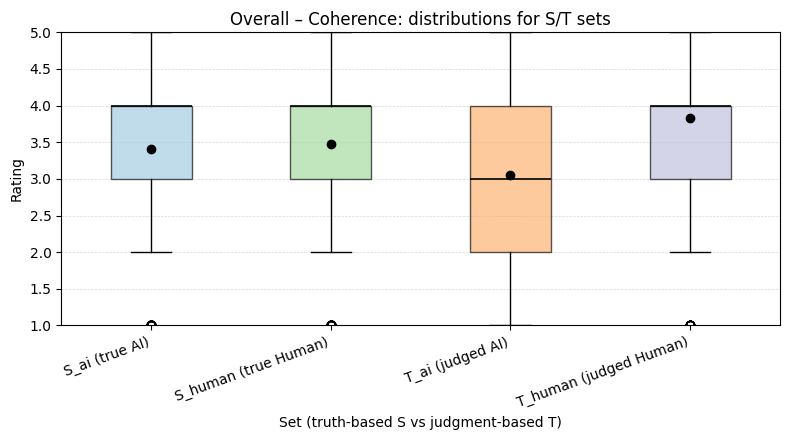

/tmp/ipython-input-839380552.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


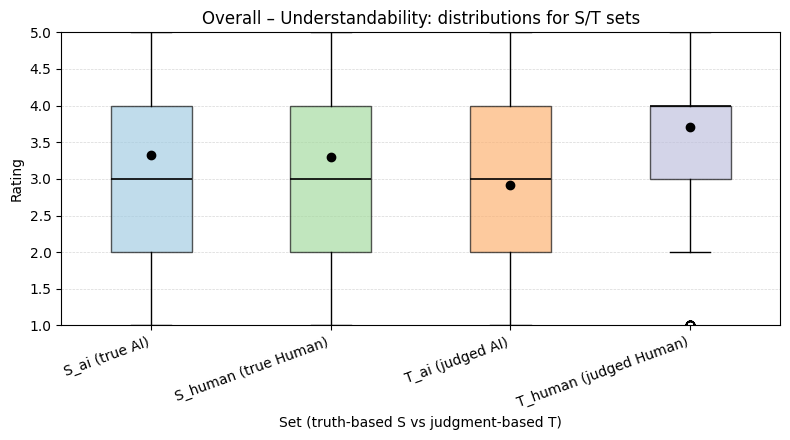

/tmp/ipython-input-839380552.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


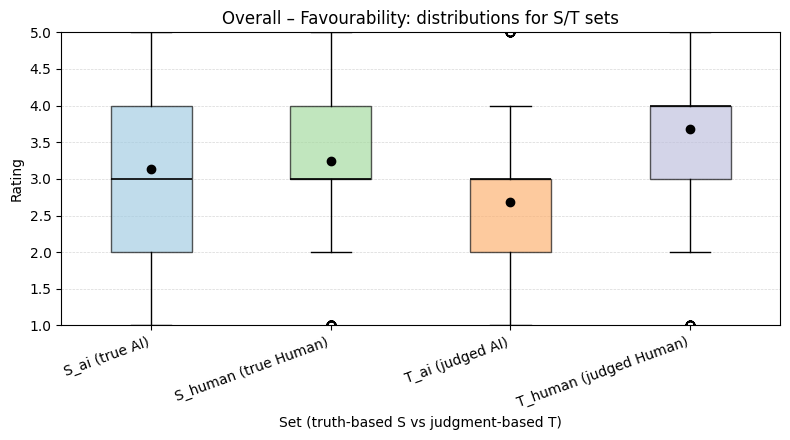

/tmp/ipython-input-839380552.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


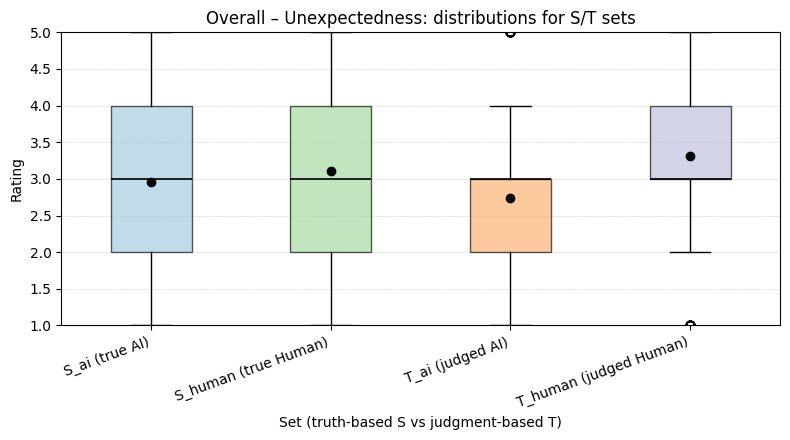

In [48]:
set_order = ["S_ai (true AI)", "S_human (true Human)", "T_ai (judged AI)", "T_human (judged Human)"]

def add_ST_set_column(long_df):
    d = long_df.copy()

    S = d.copy()
    S["ST_Set"] = np.where(S["Truth"] == "AI", "S_ai (true AI)", "S_human (true Human)")

    T = d.copy()
    T["ST_Set"] = np.where(T["Guess"] == "AI", "T_ai (judged AI)", "T_human (judged Human)")

    out = pd.concat([S, T], ignore_index=True)
    out["ST_Set"] = pd.Categorical(out["ST_Set"], categories=set_order, ordered=True)
    return out

dataset_label = "Overall"
d = add_ST_set_column(long_all)

box_colors = ["#9ecae1", "#a1d99b", "#fdae6b", "#bcbddc"]

for m in impression_metrics:
    plot_df = d[["ST_Set", m]].dropna()
    groups = [plot_df.loc[plot_df["ST_Set"] == s, m].values for s in set_order]

    fig, ax = plt.subplots(figsize=(8, 4.5))
    bp = ax.boxplot(
        groups,
        labels=set_order,
        showfliers=True,
        patch_artist=True,
        showmeans=True,
        meanprops=dict(marker="o", markerfacecolor="black",
                       markeredgecolor="black", markersize=6),
        medianprops=dict(color="black", linewidth=1.2)
    )

    for patch, c in zip(bp["boxes"], box_colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.65)
        patch.set_edgecolor("black")
        patch.set_linewidth(1.0)

    for w in bp["whiskers"]:
        w.set_color("black"); w.set_linewidth(1.0)
    for cap in bp["caps"]:
        cap.set_color("black"); cap.set_linewidth(1.0)

    ax.set_title(f"{dataset_label} – {m}: distributions for S/T sets")
    ax.set_xlabel("Set (truth-based S vs judgment-based T)")
    ax.set_ylabel("Rating")
    ax.set_xticklabels(set_order, rotation=20, ha="right")
    ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5)
    ax.set_ylim(1, 5)
    plt.tight_layout()
    plt.show()

What we observe from the boxplots is that **human-generated haikus tend to perform better** in several key aspects, with **higher ratings** in metrics such as **Poeticness** and **Coherence**. However, AI-generated haikus show **higher consistency in ratings** from the judges, a trait that could be seen as both a **strength and limitation** depending on the context of the analysis. This consistency can indicate that the models may **lack the creative nuance** that human haikus typically possess, but they also produce more **stable and predictable outcomes**.

#### Truth-based Separation (S_ai vs S_human)

The **truth-based separation** is about evaluating whether **AI haikus** (S_ai) and **Human haikus** (S_human) are **perceived differently** in terms of their **true origin**. Comparing **S_ai** vs **S_human** helps us understand whether **people experience AI-written haikus differently from human-written ones** based on their **impression ratings**.

From the boxplots, we can see that **human-generated haikus (S_human)** tend to have **higher median ratings** across many impression metrics, such as **Poeticness** and **Coherence**, compared to **AI-generated haikus (S_ai)**. This suggests that **human haikus are generally perceived more favorably** in these areas.

#### Belief-based Separation (T_ai vs T_human)

Next, we look at the **belief-based separation**: do participants use the **impression features** (like fluency, poeticness, etc.) to decide if a haiku is **AI** or **Human**? By comparing **T_ai** (the judgments for AI) and **T_human** (the judgments for human), we can analyze how participants **judge AI vs Human** haikus based on **their impressions**.

Interestingly, the **T_ai** and **T_human** boxplots show **similar distributions**, suggesting that participants' judgments of **AI-generated haikus** and **human-generated haikus** are **influenced by similar impressions** (such as fluency and coherence). However, while **human haikus** have **higher median values** in **Poeticness** and **Coherence**, there is **more variation in how raters judge** these aspects for human haikus. This highlights that **participants' decisions** are based on **similar impression metrics**, but their **judgments can be more varied** for human haikus.

#### Calibration / Mismatch (S_ai vs T_ai and S_human vs T_human)

Finally, we look at the **calibration** or **mismatch** between the true origin of haikus and how they are judged. By comparing **S_ai vs T_ai** and **S_human vs T_human**, we can determine whether the haikus participants **judge as AI or Human** are consistent with the true ratings of those haikus.

For AI, the **S_ai vs T_ai** comparison reveals that there is **some misalignment** between the **true quality of AI-generated haikus** and how they are **judged**. In contrast, the comparison for human haikus (**S_human vs T_human**) shows that participants’ **judgments align relatively well** with the true performance of human-generated haikus. This suggests that **participants are more accurate in judging human haikus** based on the **impression metrics**, but there is some **misjudgment for AI haikus** in certain areas (e.g., **Poeticness** and **Coherence**).


### ***Impression rating analysis***

#### **Fluency**

Looking at the **Fluency** ratings, we see that AI-generated haikus (**S_ai**) are rated **less fluently** than human haikus (**S_human**), with **AI judgments (T_ai)** being slightly higher. This suggests that **AI haikus** are **more inconsistent in fluency** than human ones, but **judges tend to rate AI haikus higher** than their actual fluency suggests.

#### **Haiku Wording**

For **Haiku Wording**, both **S_ai** and **T_ai** show **similar medians**, indicating that **AI models perform similarly in terms of wording** when judged and when rated for their true quality. However, human-generated haikus (**S_human**) tend to **perform better for wording** than they are judged, suggesting that **human haikus are perceived as having better wording** overall.

#### **Poeticness**

When analyzing **Poeticness**, the significant difference between **S_ai** and **T_ai** suggests that AI haikus are **judged more favorably for poeticness** than their actual performance reflects. Human haikus (**S_human**) consistently outperform AI haikus in terms of **poeticness**, as shown by the **higher median** and **narrower spread** for human haikus. The **wider spread for T_human** indicates that participants have **more varied opinions** about what makes a haiku poetic.

#### **Coherence**

In terms of **Coherence**, AI-generated haikus tend to be **judged more coherent** than they are rated for their true coherence. The **spread for both S_ai and T_ai** is similar, showing that raters generally perceive AI haikus in a consistent manner. Human-generated haikus (**S_human**) consistently outperform AI in coherence, with a **higher median** and a wider spread in **T_human**, indicating that **judges are more divided on human coherence**.

#### **Understandability**

For **Understandability**, the **S_ai** boxplot is slightly **higher than T_ai**, suggesting that **AI haikus are considered more understandable** than they are judged by participants. On the other hand, **S_human** haikus are seen as **more understandable** than **T_human**, with the **wider spread in T_human** showing more **variability** in how human haikus are judged.

#### **Favourability**

In terms of **Favourability**, both **S_ai** and **T_ai** are fairly **similar**, suggesting that AI haikus are judged similarly for their **overall favourability**. **Human-generated haikus** tend to show a **higher median** for **S_human**, indicating that human haikus are **rated more favorably** than AI haikus. The **wider spread in T_human** indicates that raters have **more diverse opinions** on human haikus.

#### **Unexpectedness**

For **Unexpectedness**, **S_ai** and **T_ai** are relatively **similar**, indicating that AI-generated haikus are judged similarly for their **unexpectedness**. Human-generated haikus (**S_human**) tend to be seen as more **unexpected** than AI-generated ones, with **wider spread** in **T_human**, again suggesting **greater diversity** in human judgment.

<br>

From this analysis, we can conclude that **human-generated haikus** consistently **perform better in terms of creativity**, such as **Poeticness**, **Coherence**, and **Favourability**, but AI-generated haikus show **more consistent judgments** across raters. The comparison between **S and T sets** reveals that **participants’ judgments align more closely with the true performance of human haikus**, while there’s a **larger discrepancy** for AI-generated haikus in metrics like **Poeticness** and **Coherence**.

This analysis helps us understand not just how AI and human haikus compare in terms of their true quality, but also how **raters’ judgments are influenced by the impression metrics** in their decisions to classify a haiku as AI or Human. By evaluating these unified boxplots, we get a **comprehensive view** of the **impression-based differences** between AI and human haikus across various models.

---

### ***Overall Conclusion on the Confusion Matrices - One Per Model***

Across all six models, we observe a recurring **misclassification of human haikus as AI** (Human → AI), especially in the earlier versions. This pattern suggests that **human haikus are often misclassified as AI**, indicating that the model struggles with **discriminating between human and AI haikus** in these versions. This **misclassification** can happen for several reasons, one of which is a **response bias** in which participants are more likely to **attribute human haikus to AI**, possibly because **human haikus** in these versions have certain qualities that the model associates with **AI-generated content**.

The **AI→Human misclassification** reflects a situation where **AI haikus** are sometimes misidentified as **human** content, but in most of the models, this bias is less pronounced. The **Human→AI misclassification** suggests that the model is **more likely to misclassify human-generated content as AI**—potentially because **human haikus** might have characteristics such as **structured wording** or **fluent phrasing** that can be perceived as more **AI-like**. This aligns with the idea that the **AI models** have become increasingly adept at generating fluent, coherent, and sometimes overly structured content that **mimics** the **polished qualities** typically associated with human writing. However, due to their **highly formulaic nature**, these AI-generated haikus are still **misclassified as human** content, despite being computationally generated.

As we move through the models, we notice that **accuracy improves** (especially in the **LLaMA** and **instruct4 models**), and **misclassification rates** decrease, particularly for **AI→Human misclassification**. These improvements suggest that **the model's source discrimination abilities are improving** with time, as the ability to differentiate between **AI and Human haikus** becomes **sharper**. The **AI attribution bias** is **diminishing** with newer models, as they exhibit more **balanced performance** and **stronger calibration** between AI and human haikus.

In models where **accuracy is higher** (e.g., **LLaMA** and **instruct4** with **accuracy of 0.670 and 0.590**), we see that **AI and human haikus are more accurately identified**, with **fewer false positives** and **missed detections**. However, despite this improvement, **human haikus are still often misclassified as AI** in these later models, which could be a reflection of the **human-like quality** present in **AI-generated haikus**. This is an indication that **AI-generated haikus** have become **sophisticated enough** to resemble **human-like qualities**, such as fluency and structure, which can sometimes confuse the model. Nonetheless, the **improvements in accuracy** across the models indicate that the models are **becoming more accurate in distinguishing between AI and human haikus**, as they progressively reduce the **AI→Human misclassification**.

Overall, these confusion matrices reveal that the **source discrimination** between **AI and Human haikus** is still **moderate**, with some **biases in classification**. While the **AI attribution bias** is still present in earlier models, it decreases as the models evolve, leading to more **balanced** and **accurate classifications** of AI and human haikus. The results suggest that the models are **getting better at recognizing AI and human haikus**, but there is still **room for further improvement** to **reduce misclassifications** and enhance their **discriminatory abilities**.

These improvements are encouraging, but **further refinements** are necessary to **achieve more robust performance** and eliminate any remaining **bias** in classifying AI-generated and human-generated haikus. The **human-like qualities** of **AI-generated content** continue to pose a challenge, but as we move forward, the models will likely **refine their ability to distinguish** between the two sources more effectively.

---

### 2. **How respondents background is linked to being able to recognize AI vs human?**

In [49]:
df_chat_GPT5 = pd.read_csv('/content/drive/MyDrive/DATA SCIENCE 23 24/THESIS/SIT /df_chat_GPT5.csv')
df_gamma_GAMMA = pd.read_csv('/content/drive/MyDrive/DATA SCIENCE 23 24/THESIS/SIT /df_gamma_GAMMA.csv')
df_gemini_GEMINI = pd.read_csv('/content/drive/MyDrive/DATA SCIENCE 23 24/THESIS/SIT /df_gemini_GEMINI.csv')
df_gemma_GEMMA = pd.read_csv('/content/drive/MyDrive/DATA SCIENCE 23 24/THESIS/SIT /df_gemma_GEMMA.csv')
df_llama_LLaMA = pd.read_csv('/content/drive/MyDrive/DATA SCIENCE 23 24/THESIS/SIT /df_llama_LLaMA.csv')
df_instruct4 = pd.read_csv('/content/drive/MyDrive/DATA SCIENCE 23 24/THESIS/SIT /df_instruct4.csv')

In [50]:
#making one dataset out of the 6 ones I have from the different models I used to create the haiku

df_chat_GPT5['Model'] = 'GPT5'
df_gamma_GAMMA['Model'] = 'GAMMA'
df_gemini_GEMINI['Model'] = 'GEMINI'
df_gemma_GEMMA['Model'] = 'GEMMA'
df_llama_LLaMA['Model'] = 'LLaMA'
df_instruct4['Model'] = 'instruct4'

df_chat = pd.concat([df_chat_GPT5, df_gamma_GAMMA, df_gemini_GEMINI, df_gemma_GEMMA, df_llama_LLaMA, df_instruct4], ignore_index=True)

#### ***Logistic regression***

During model construction, University_name and Grade_department were found to be highly collinear. This is due to the structure of the sample, where each university is associated with a specific and largely non-overlapping set of departments. As a consequence, including both variables led to redundancy in the regression model. For this reason, only one of the two predictors was retained. We chose Grade_department, as it more directly reflects participants’ academic background, while University_name was used only for descriptive purposes.
The same was done with "Language" and "Japanese_proficiency", where the "Japanese_proficiency" was retained while the "Language" was kept as a descriptor.

Since the research question concerns respondents’ background, we analyzed performance at the respondent level. With only 24 participants and several categorical predictors, standard logistic regression was unstable due to collinearity and sparse categories. We used ridge logistic regression to stabilize estimates and report odds ratios as descriptive effect sizes.

In [51]:
df_part = df_chat.copy()

# binary outcome: above-chance recognition (since the research question syas "being able to", it can be translated in above-chance recognition)
df_part["Above_chance"] = (df_part["Accuracy"] > 0.5).astype(int)

#### ***Aggregation scheme***

`STEM = Engineering + Computer Science + Architecture (built environment fits here for training style / quantitative orientation)`
Grade_department_4th year, Department of Information Engineering<br>
Grade_department_1st year, Department of Information Engineering<br>
Grade_department_3rd year, Department of Information Engineering<br>
Grade_department_2nd year of Master, Department of Mechnaical Engineering<br>
Grade_department_4th year, Faculty of Engineering, Department of Information and Communication Engineering<br>
Grade_department_Master's 2nd Year, Department of Electrical, Electronic, and Information Engineering<br>
Grade_department_2nd-year graduate student, Department of Electrical, Electronic and Information Engineering<br>
Grade_department_4th year, Department of Science and Engineering<br>
Grade_department_1st year of Master, Department of International Science and Engineering<br>
Grade_department_1st year Master, Department of Electrical, Electronic, and Information Engineering<br>
Grade_department_4th year, Department of Engeneering<br>
Grade_department_Department of Engineering<br>
Grade_department_2nd-year graduate student, Software Engineering<br>
Grade_department_Department of Science and Engineering<br>
Grade_department_Department of Biomedical engineering<br>
Grade_department_2nd year of Master, Department of Civil Engineering<br>
Grade_department_1st year of Master, Department of Electrical, Electronic, and Information Engineering<br>
Grade_department_4th year, Department of Electronic Engineering<br>
Grade_department_4th year, Department of Computer Science<br>
Grade_department_Department of Computer Science<br>
Grade_department_2nd year of Master, Department of Computer Science<br>
Grade_department_2nd Year, Department of Computer Science<br>
Grade_department_1st year of Master, Department of Computer Science<br>
Grade_department_3rd year, Department of Computer Science<br>
Grade_department_Master, Department of Computer Science<br>
Grade_department_2nd year, Department of Architecture-SA<br>
Grade_department_4th year, Department of Architecture<br>
Grade_department_2nd year of Bachelor, Department of Architecture<br>


`Social Sciences = Liberal Arts + Policy + Law + Marine Policy & Culture + Economics (+ Humanities)`<br>
Grade_department_4th year, Department of Contemporary Cultural Expression<br>
Grade_department_3rd year, Department of of Arts and Humanities<br>
Grade_department_3rd year, Department of International Liberal Arts<br>
Grade_department_3rd year Undergraduate, Department of Liberal Arts<br>
Grade_department_3rd year Undergraduate, Department of Liberal Arts<br>
Grade_department_2nd year, Department of Marine Policy and Culture Studies<br>
Grade_department_4th year, Department of Law<br>
Grade_department_4th year, Department Public Policy<br>
Grade_department_4th year, Department of Economics<br>


`Psychology (keep separate if it has decent N; otherwise merge into bucket 2) & HUmanities`
Grade_department_2nd year of Master, Department of Clinical psychology<br>
Grade_department_3rd year, Department of Clinical Psychology<br>
Grade_department_1st year of Master, Department of Clinical Psychology<br>
Grade_department_4th year, Department of Clinical Psychology<br>
Grade_department_3rd year, Clinical Psychology<br>
Grade_department_1st year, Department of Clinical Psychology<br>
Grade_department_2nd year, Department of Clinical psychology<br>
Grade_department_4th year, Department of Life and Psychological Sciences<br>
Grade_department_2nd year, Department of Clinical Psychology<br>
Grade_department_Department of Clinical Psychology<br>
Grade_department_4th year, Department of Psychology<br>
Grade_department_3d year, Department of Clinical Psychology<br>
Grade_department_4th year, Department of Humanities<br>
Grade_department_3rd year, Department of Humanities<br>


`Unknown / No department`<br>
Grade_department_2nd year of Master<br>
Grade_department_4th year, no department<br>
Grade_department_First year - no department<br>
Grade_department_3rd year - no department<br>
Grade_department_1st year of Master<br>
Grade_department_4th year<br>
Grade_department_1st year, Master<br>
Grade_department_3rd year


In [52]:
# Aggregate Grade_department into broad buckets

def map_grade_group(x):
    if pd.isna(x):
        return "Unknown/No department"
    s = str(x).strip().lower()

    # Unknown / no department (and year-only entries)
    if "no department" in s or s in {
        "2nd year of master",
        "1st year of master",
        "1st year, master",
        "4th year",
        "3rd year",
        "first year - no department",
        "3rd year - no department",
        "4th year, no department",
    }:
        return "Unknown/No department"

    # Psychology
    if "psychology" in s or "clinical psychology" in s or "life and psychological sciences" in s:
        return "Psychology"

    # STEM = Engineering + CS + Architecture
    if ("engineer" in s) or ("engeneer" in s) or any(k in s for k in [
        "computer science", "architecture", "electrical", "electronic",
        "mechanical", "civil", "biomedical", "software", "science and engineering",
        "information engineering", "communication engineering"
    ]):
        return "STEM"

    # Social Sciences / Humanities / Law / Policy / Economics / Liberal Arts
    if any(k in s for k in [
        "liberal arts", "humanities", "arts and humanities",
        "cultural expression", "marine policy", "policy", "law", "economics"
    ]):
        return "Social Sciences/Humanities"

df_part["Grade_group"] = df_part["Grade_department"].apply(map_grade_group)

cat_order = ["Social Sciences/Humanities", "STEM", "Psychology", "Unknown/No department"]
df_part["Grade_group"] = pd.Categorical(df_part["Grade_group"], categories=cat_order, ordered=True)

print("Grade_group counts:\n", df_part["Grade_group"].value_counts(dropna=False))

# Set Haiku_experience baseline to "Rarely"
haiku_exp_order = ["Rarely", "Occasionally", "A few/month", "1/2 per week"]
df_part["Haiku_experience"] = (
    df_part["Haiku_experience"]
    .astype(str)
    .str.strip()
)
df_part["Haiku_experience"] = pd.Categorical(
    df_part["Haiku_experience"],
    categories=haiku_exp_order,
    ordered=True
)

print("Haiku_experience counts:\n", df_part["Haiku_experience"].value_counts(dropna=False))

# predictors
X_cols = ["Grade_group", "Japanese_proficiency", "Haiku_experience", "Haiku_composition"]

df_part2 = df_part[["Above_chance"] + X_cols].dropna().copy()

# one-hot encode categoricals
X = pd.get_dummies(df_part2[X_cols], drop_first=True)
y = df_part2["Above_chance"].values

print("N respondents used:", len(df_part2))
print("N features:", X.shape[1])
print("Class balance (Above_chance=1):", y.mean().round(3))

# Fit
clf = LogisticRegression(penalty="l2", C=1.0, solver="liblinear", max_iter=5000)
clf.fit(X, y)

coefs = pd.Series(clf.coef_[0], index=X.columns).sort_values(key=np.abs, ascending=False)

results_df = pd.DataFrame({
    "feature": coefs.index,
    "coef": coefs.values,
    "odds_ratio": np.exp(coefs.values)
})

# Cross-validated AUC
cv_splits = 3  # or 5 folds
cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=42)

clf_cv = LogisticRegression(penalty="l2", C=1.0, solver="liblinear", max_iter=5000)
probs_cv = cross_val_predict(clf_cv, X, y, cv=cv, method="predict_proba")[:, 1]
auc_cv = roc_auc_score(y, probs_cv)

print(f"AUC (CV {cv_splits}-fold):", round(auc_cv, 3))


out_path = "/content/drive/MyDrive/DATA SCIENCE 23 24/THESIS/SIT /logreg_coefficients.csv"
results_df.to_csv(out_path, index=False)

print("Saved to:", out_path)
print(results_df)

Grade_group counts:
 Grade_group
Psychology                    48
STEM                          43
Social Sciences/Humanities    39
Unknown/No department         14
Name: count, dtype: int64
Haiku_experience counts:
 Haiku_experience
Occasionally    120
Rarely           12
A few/month      10
1/2 per week      2
Name: count, dtype: int64
N respondents used: 144
N features: 14
Class balance (Above_chance=1): 0.507
AUC (CV 3-fold): 0.416
Saved to: /content/drive/MyDrive/DATA SCIENCE 23 24/THESIS/SIT /logreg_coefficients.csv
                              feature      coef  odds_ratio
0             Japanese_proficiency_N1 -0.777975    0.459335
1                    Grade_group_STEM  0.567489    1.763832
2            Haiku_composition_Rarely -0.440907    0.643453
3             Japanese_proficiency_N2 -0.392599    0.675300
4        Haiku_experience_A few/month  0.353971    1.424713
5   Japanese_proficiency_None/Unknown -0.351074    0.703931
6             Japanese_proficiency_N5 -0.176280    0

#### ***Language proficiency only model***

In [53]:
# -----------------------------
# 1) Grade_group mapping
# -----------------------------
def map_grade_group(x):
    if pd.isna(x):
        return "Unknown/No department"
    s = str(x).strip().lower()

    if "no department" in s or s in {
        "2nd year of master",
        "1st year of master",
        "1st year, master",
        "4th year",
        "3rd year",
        "first year - no department",
        "3rd year - no department",
        "4th year, no department",
    }:
        return "Unknown/No department"

    if "psychology" in s or "clinical psychology" in s or "life and psychological sciences" in s:
        return "Psychology"

    if ("engineer" in s) or ("engeneer" in s) or any(k in s for k in [
        "computer science", "architecture", "electrical", "electronic",
        "mechanical", "civil", "biomedical", "software", "science and engineering",
        "information engineering", "communication engineering"
    ]):
        return "STEM"

    if any(k in s for k in [
        "liberal arts", "humanities", "arts and humanities",
        "cultural expression", "marine policy", "policy", "law", "economics"
    ]):
        return "Social Sciences/Humanities"

df_part["Grade_group"] = df_part["Grade_department"].apply(map_grade_group)

# Baseline for Grade_group = Social Sciences/Humanities
grade_order = ["Social Sciences/Humanities", "STEM", "Psychology", "Unknown/No department"]
df_part["Grade_group"] = pd.Categorical(df_part["Grade_group"], categories=grade_order, ordered=True)

print("Grade_group counts:\n", df_part["Grade_group"].value_counts(dropna=False))

# -----------------------------
# 2) Haiku_experience baseline = Rarely
# -----------------------------
haiku_exp_order = ["Rarely", "Occasionally", "A few/month", "1/2 per week"]
df_part["Haiku_experience"] = df_part["Haiku_experience"].astype("string").str.strip()
df_part["Haiku_experience"] = pd.Categorical(
    df_part["Haiku_experience"],
    categories=haiku_exp_order,
    ordered=True
)
print("Haiku_experience counts:\n", df_part["Haiku_experience"].value_counts(dropna=False))

# -----------------------------
# 3) Haiku_composition baseline = Never
# -----------------------------
haiku_comp_order = ["Never", "Rarely", "Occasionally", "Sometimes"]
df_part["Haiku_composition"] = df_part["Haiku_composition"].astype("string").str.strip()
df_part["Haiku_composition"] = pd.Categorical(
    df_part["Haiku_composition"],
    categories=haiku_comp_order,
    ordered=True
)
print("Haiku_composition counts:\n", df_part["Haiku_composition"].value_counts(dropna=False))

# -----------------------------
# 4) Japanese proficiency baseline = Mother tongue
# -----------------------------
jp_order = ["Mother tongue", "N5", "N4", "N2", "N1", "None/Unknown"]  # keep your preferred order
df_part["Japanese_proficiency"] = df_part["Japanese_proficiency"].astype("string").str.strip()
df_part["Japanese_proficiency"] = pd.Categorical(
    df_part["Japanese_proficiency"],
    categories=jp_order,
    ordered=True
)
print("Japanese_proficiency counts:\n", df_part["Japanese_proficiency"].value_counts(dropna=False))

# -----------------------------
# 5) Build one full design matrix, then subset columns per model
# -----------------------------
all_predictors = ["Grade_group", "Japanese_proficiency", "Haiku_experience", "Haiku_composition"]

df_model = df_part[["Above_chance"] + all_predictors].dropna().copy()
y = df_model["Above_chance"].values

X_full = pd.get_dummies(df_model[all_predictors], drop_first=True)

print("N respondents used:", len(df_model))
print("N full features:", X_full.shape[1])
print("Class balance (Above_chance=1):", y.mean().round(3))

# Helper: fit model and return results table
def fit_and_summarize(X, y, out_path=None, label="model", cv_splits=3):
    # fit on full data
    clf = LogisticRegression(penalty="l2", C=1.0, solver="liblinear", max_iter=5000)
    clf.fit(X, y)

    coefs = pd.Series(clf.coef_[0], index=X.columns).sort_values(key=np.abs, ascending=False)

    results = pd.DataFrame({
        "feature": coefs.index,
        "coef": coefs.values,
        "odds_ratio": np.exp(coefs.values),
    })

    # CV AUC (out-of-sample)
    cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=42)
    clf_cv = LogisticRegression(penalty="l2", C=1.0, solver="liblinear", max_iter=5000)
    probs_cv = cross_val_predict(clf_cv, X, y, cv=cv, method="predict_proba")[:, 1]
    auc_cv = roc_auc_score(y, probs_cv)

    print(f"\n[{label}] N features:", X.shape[1])
    print(f"[{label}] AUC (CV {cv_splits}-fold):", round(auc_cv, 3))
    print(results)

    if out_path is not None:
        results.to_csv(out_path, index=False)
        print("Saved to:", out_path)

    return results, clf, auc_cv

Grade_group counts:
 Grade_group
Psychology                    48
STEM                          43
Social Sciences/Humanities    39
Unknown/No department         14
Name: count, dtype: int64
Haiku_experience counts:
 Haiku_experience
Occasionally    120
Rarely           12
A few/month      10
1/2 per week      2
Name: count, dtype: int64
Haiku_composition counts:
 Haiku_composition
Never           77
Occasionally    64
Sometimes        2
Rarely           1
Name: count, dtype: int64
Japanese_proficiency counts:
 Japanese_proficiency
Mother tongue    128
None/Unknown       7
N5                 4
N4                 2
N1                 2
N2                 1
Name: count, dtype: int64
N respondents used: 144
N full features: 14
Class balance (Above_chance=1): 0.507


In [54]:
# -----------------------------
# 6A) Language proficiency ONLY model
# -----------------------------
lang_cols = [c for c in X_full.columns if c.startswith("Japanese_proficiency_")]
X_lang = X_full[lang_cols]

out_path_lang = "/content/drive/MyDrive/DATA SCIENCE 23 24/THESIS/SIT /logreg_language_only.csv"
res_lang, clf_lang, auc_lang = fit_and_summarize(
    X_lang, y, out_path=out_path_lang, label="LANGUAGE ONLY", cv_splits=3
)
print(round(auc_lang, 3))


[LANGUAGE ONLY] N features: 5
[LANGUAGE ONLY] AUC (CV 3-fold): 0.456
                             feature      coef  odds_ratio
0            Japanese_proficiency_N1 -0.690281    0.501435
1            Japanese_proficiency_N2 -0.410726    0.663169
2  Japanese_proficiency_None/Unknown -0.213748    0.807552
3            Japanese_proficiency_N5 -0.024921    0.975387
4            Japanese_proficiency_N4 -0.016604    0.983533
Saved to: /content/drive/MyDrive/DATA SCIENCE 23 24/THESIS/SIT /logreg_language_only.csv
0.456


#### ***Withouth language proficiency model***

In [55]:
# -----------------------------
# 6B) ALL predictors EXCEPT language proficiency
# -----------------------------
nonlang_cols = [c for c in X_full.columns if not c.startswith("Japanese_proficiency_")]
X_nonlang = X_full[nonlang_cols]

out_path_nonlang = "/content/drive/MyDrive/DATA SCIENCE 23 24/THESIS/SIT /logreg_no_language.csv"
res_nonlang, clf_nonlang, auc_nonlang = fit_and_summarize(
    X_nonlang, y, out_path=out_path_nonlang, label="NO LANGUAGE", cv_splits=3
)
print(-round(auc_nonlang, 3))


[NO LANGUAGE] N features: 9
[NO LANGUAGE] AUC (CV 3-fold): 0.432
                             feature      coef  odds_ratio
0                   Grade_group_STEM  0.495866    1.641919
1       Haiku_experience_A few/month  0.421061    1.523577
2           Haiku_composition_Rarely -0.414164    0.660893
3      Haiku_experience_Occasionally  0.239922    1.271150
4     Haiku_composition_Occasionally  0.180912    1.198310
5  Grade_group_Unknown/No department  0.119098    1.126480
6        Haiku_composition_Sometimes -0.049022    0.952160
7      Haiku_experience_1/2 per week  0.010057    1.010108
8             Grade_group_Psychology  0.009919    1.009968
Saved to: /content/drive/MyDrive/DATA SCIENCE 23 24/THESIS/SIT /logreg_no_language.csv
-0.432


### ***3. Which cues drive correct recognition among the impression ratings: Logistic regression analysis.***
- Sub-questions: <br>What makes a haiku feel human?<br>
What makes a haiku feel Ai?

In [56]:
long_all_theme_GPT5 = pd.read_csv('/content/drive/MyDrive/DATA SCIENCE 23 24/THESIS/SIT /long_all_theme_GPT5.csv')
long_all_theme_GAMMA = pd.read_csv('/content/drive/MyDrive/DATA SCIENCE 23 24/THESIS/SIT /long_all_theme_gamma.csv')
long_all_theme_GEMINI = pd.read_csv('/content/drive/MyDrive/DATA SCIENCE 23 24/THESIS/SIT /long_all_theme_Gemini.csv')
long_all_theme_GEMMA = pd.read_csv('/content/drive/MyDrive/DATA SCIENCE 23 24/THESIS/SIT /long_all_theme_gemma.csv')
long_all_theme_LLaMA = pd.read_csv('/content/drive/MyDrive/DATA SCIENCE 23 24/THESIS/SIT /long_all_theme_LLaMA.csv')
long_all_theme_instruct4 = pd.read_csv('/content/drive/MyDrive/DATA SCIENCE 23 24/THESIS/SIT /long_all_theme_instruct4.csv')

In [57]:
#making one dataset out of the 6 ones I have from the different models I used to create the haiku
long_all_theme = pd.concat([long_all_theme_GPT5, long_all_theme_GAMMA, long_all_theme_GEMINI, long_all_theme_GEMMA, long_all_theme_LLaMA, long_all_theme_instruct4], ignore_index=True)
long_all_theme.head(3)

,Dataset,Respondent,Haiku,Fluency,Haiku_Wording,Poeticness,Coherence,Understandability,Favourability,Unexpectedness,Theme_Relevance,Correct,Judged_Human
0,AW,0,1,4.0,4.0,2.0,3.0,5.0,2.0,1.0,1.0,1,0
1,AW,0,2,1.0,1.0,2.0,2.0,1.0,1.0,3.0,1.0,0,0
2,AW,0,3,2.0,1.0,2.0,3.0,2.0,2.0,4.0,2.0,0,0


#### ***RQ 3.1 Which cues drive correct recognition among the impression ratings***

Logistic regression

In [58]:
X_cols = [
    "Fluency",
    "Haiku_Wording",
    "Poeticness",
    "Coherence",
    "Understandability",
    "Favourability",
    "Unexpectedness",
    "Theme_Relevance"
]

df_m = long_all_theme[X_cols + ["Correct", "Judged_Human"]].dropna().copy()

print("N rows used:", len(df_m))
print("Correct rate:", df_m["Correct"].mean().round(3))
print("Judged_Human rate:", df_m["Judged_Human"].mean().round(3))

X = df_m[X_cols].values

# print coef and OR
def run_logreg(y_col, title, cv_splits=5):
    y = df_m[y_col].values

    # fit on full data for coefficients
    clf = LogisticRegression(penalty="l2", C=1.0, solver="liblinear", max_iter=5000)
    clf.fit(X, y)

    res = pd.DataFrame({
        "feature": X_cols,
        "coef": clf.coef_[0],
        "odds_ratio": np.exp(clf.coef_[0])
    }).sort_values("coef", key=np.abs, ascending=False)

    # CV-AUC (out-of-sample)
    cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=42)
    clf_cv = LogisticRegression(penalty="l2", C=1.0, solver="liblinear", max_iter=5000)
    probs_cv = cross_val_predict(clf_cv, X, y, cv=cv, method="predict_proba")[:, 1]
    auc_cv = roc_auc_score(y, probs_cv)

    print("\n" + title)
    print(f"AUC (CV {cv_splits}-fold):", round(auc_cv, 3))
    print(res.to_string(index=False))

    return res, auc_cv

N rows used: 1724
Correct rate: 0.566
Judged_Human rate: 0.506


In [59]:
res_correct, auc_correct = run_logreg("Correct", "MODEL 1: CUES → CORRECT (main question)", cv_splits=5)
res_correct.to_csv('/content/drive/MyDrive/DATA SCIENCE 23 24/THESIS/SIT /logreg_RQ3.1.csv', index=False)
print("CV-AUC:", round(auc_correct, 3))


MODEL 1: CUES → CORRECT (main question)
AUC (CV 5-fold): 0.505
          feature      coef  odds_ratio
    Favourability -0.181864    0.833715
Understandability  0.083394    1.086970
  Theme_Relevance  0.080421    1.083743
   Unexpectedness  0.069205    1.071655
          Fluency  0.058298    1.060031
       Poeticness -0.039531    0.961240
        Coherence -0.015973    0.984154
    Haiku_Wording -0.013065    0.987020
CV-AUC: 0.505


Mixed effect:<br>
Correct ~ Fluency + Haiku_Wording + Poeticness + Coherence +
          Understandability + Favourability + Unexpectedness +
          Theme_Relevance
          + (1 | Judge) + (1 | Poem)

In [60]:
# predictors
X_cols = [
    "Fluency",
    "Haiku_Wording",
    "Poeticness",
    "Coherence",
    "Understandability",
    "Favourability",
    "Unexpectedness",
    "Theme_Relevance"
]

# Must include Respondent and Haiku for random effects
df_m = long_all_theme[["Respondent", "Haiku"] + X_cols + ["Correct", "Judged_Human"]].dropna().copy()

print("N rows used:", len(df_m))
print("Correct rate:", round(df_m["Correct"].mean(), 3))
print("Judged_Human rate:", round(df_m["Judged_Human"].mean(), 3))

def run_glmm(y_col, title):
    # fixed effects formula
    fe_formula = y_col + " ~ " + " + ".join(X_cols)

    # random intercepts
    vc_formulas = {
        "Respondent": "0 + C(Respondent)",
        "Haiku": "0 + C(Haiku)"
    }

    # fit GLMM (logit link, binomial)
    model = BinomialBayesMixedGLM.from_formula(fe_formula, vc_formulas, df_m)

    # variational Bayes fit
    fit = model.fit_vb()

    # Extract fixed effects (log-odds) + SD
    fe_names = model.exog_names
    fe_mean  = pd.Series(fit.fe_mean, index=fe_names)
    fe_sd    = pd.Series(fit.fe_sd, index=fe_names)

    res = pd.DataFrame({
        "feature": fe_mean.index,
        "coef": fe_mean.values,
        "sd": fe_sd.values,
        "odds_ratio": np.exp(fe_mean.values)
    })

    res_no_intercept = res[res["feature"] != "Intercept"].copy()
    res_no_intercept = res_no_intercept.sort_values("coef", key=np.abs, ascending=False)

    print("\n" + title)
    print(res_no_intercept.to_string(index=False))

    return res_no_intercept, fit

N rows used: 1724
Correct rate: 0.566
Judged_Human rate: 0.506


In [61]:
# RQ3.1 mixed-effects version (Correct Recognition)
res_glmm_correct, fit_correct = run_glmm("Correct", "GLMM: CUES → CORRECT (random intercepts: Respondent + Haiku)")
res_glmm_correct.to_csv('/content/drive/MyDrive/DATA SCIENCE 23 24/THESIS/SIT /mixed_effect_RQ3_1.csv', index=False)


GLMM: CUES → CORRECT (random intercepts: Respondent + Haiku)
          feature      coef       sd  odds_ratio
    Favourability -0.188966 0.014432    0.827815
Understandability  0.080659 0.013900    1.084002
   Unexpectedness  0.076530 0.015228    1.079535
  Theme_Relevance  0.075396 0.012883    1.078312
          Fluency  0.052788 0.013638    1.054206
       Poeticness -0.041636 0.013451    0.959218
        Coherence -0.017508 0.013553    0.982644
    Haiku_Wording -0.008668 0.013959    0.991370


#### ***RQ 3.2 What makes haiku feel like Human?***

Mixed effects

In [62]:
res_glmm_human, fit_human = run_glmm("Judged_Human", "GLMM: CUES → JUDGED_HUMAN (random intercepts: Respondent + Haiku)")
res_glmm_human.to_csv('/content/drive/MyDrive/DATA SCIENCE 23 24/THESIS/SIT /mixed_effect_RQ3_2.csv', index=False)


GLMM: CUES → JUDGED_HUMAN (random intercepts: Respondent + Haiku)
          feature      coef       sd  odds_ratio
    Favourability  0.539466 0.016896    1.715091
    Haiku_Wording  0.309418 0.016220    1.362631
  Theme_Relevance  0.286363 0.014761    1.331576
   Unexpectedness  0.201238 0.017786    1.222916
        Coherence  0.141988 0.015673    1.152563
          Fluency  0.112324 0.015777    1.118875
Understandability  0.072880 0.016130    1.075601
       Poeticness -0.030810 0.015581    0.969660


Logistic

In [63]:
# keep only needed cols + drop missing (include Respondent for grouped CV)
df_m = long_all_theme[["Respondent"] + X_cols + ["Judged_Human"]].dropna().copy()

print("N rows used:", len(df_m))
print("Judged_Human rate:", df_m["Judged_Human"].mean().round(3))

X = df_m[X_cols].to_numpy()
y = df_m["Judged_Human"].to_numpy().astype(int)
groups = df_m["Respondent"].to_numpy()

# 2) grouped CV-AUC helper (by Respondent)
def grouped_cv_auc(X, y, groups, n_splits=5):
    gkf = GroupKFold(n_splits=n_splits)
    probs = np.zeros(len(y), dtype=float)

    for train_idx, test_idx in gkf.split(X, y, groups):
        clf_cv = LogisticRegression(
            penalty="l2", C=1.0, solver="liblinear", max_iter=5000
        )
        clf_cv.fit(X[train_idx], y[train_idx])
        probs[test_idx] = clf_cv.predict_proba(X[test_idx])[:, 1]

    return roc_auc_score(y, probs)

# 3) fit + print coefficients/OR + grouped CV-AUC
def run_logreg(y_vec, title, cv_splits=5):
    # fit on full data
    clf = LogisticRegression(penalty="l2", C=1.0, solver="liblinear", max_iter=5000)
    clf.fit(X, y_vec)

    res = pd.DataFrame({
        "feature": X_cols,
        "coef": clf.coef_[0],
        "odds_ratio": np.exp(clf.coef_[0])
    }).sort_values("coef", key=np.abs, ascending=False)

    # grouped out-of-sample AUC (Respondent-level split)
    auc_cv = grouped_cv_auc(X, y_vec, groups, n_splits=cv_splits)

    print("\n" + title)
    print(f"AUC (Grouped CV by Respondent, {cv_splits}-fold):", round(auc_cv, 3))
    print(res.to_string(index=False))

    return res, auc_cv

# 4) cues -> judged human
res_human, auc_human = run_logreg(
    y,
    "MODEL 2: CUES → JUDGED_HUMAN (sub-question: feels human)",
    cv_splits=5
)

res_human.to_csv("/content/drive/MyDrive/DATA SCIENCE 23 24/THESIS/SIT /logreg_RQ3.2_feelsHuman.csv", index=False)

print("Grouped AUC:", round(auc_human, 3))

N rows used: 1724
Judged_Human rate: 0.506

MODEL 2: CUES → JUDGED_HUMAN (sub-question: feels human)
AUC (Grouped CV by Respondent, 5-fold): 0.794
          feature      coef  odds_ratio
    Favourability  0.529176    1.697533
    Haiku_Wording  0.286843    1.332214
  Theme_Relevance  0.257440    1.293614
   Unexpectedness  0.191137    1.210626
        Coherence  0.129518    1.138279
          Fluency  0.094909    1.099559
Understandability  0.050535    1.051834
       Poeticness -0.042525    0.958367
Grouped AUC: 0.794


#### ***RQ 3.3 What makes haiku feel like AI?***

Logistic

In [64]:
# 5) EXTRA: cues -> judged AI (what feels AI?)

# keep only needed cols + drop missing (include Respondent for grouped CV)
df_m = long_all_theme[["Respondent"] + X_cols + ["Judged_Human"]].dropna().copy()

# Now y will be the Judged_AI target (1 - Judged_Human)
y_ai = (1 - df_m["Judged_Human"]).to_numpy().astype(int)
X = df_m[X_cols].to_numpy()
groups = df_m["Respondent"].to_numpy()

# 2) grouped CV-AUC helper (by Respondent) - Redefine locally
def grouped_cv_auc(X_val, y_val, groups_val, n_splits=5):
    gkf = GroupKFold(n_splits=n_splits)
    probs = np.zeros(len(y_val), dtype=float)

    for train_idx, test_idx in gkf.split(X_val, y_val, groups_val):
        clf_cv = LogisticRegression(
            penalty="l2", C=1.0, solver="liblinear", max_iter=5000
        )
        clf_cv.fit(X_val[train_idx], y_val[train_idx])
        probs[test_idx] = clf_cv.predict_proba(X_val[test_idx])[:, 1]

    return roc_auc_score(y_val, probs)

# 3) fit + print coefficients/OR + grouped CV-AUC - Redefine locally
def run_logreg_grouped_cv(y_vec, title, cv_splits=5):
    # fit on full data
    clf = LogisticRegression(penalty="l2", C=1.0, solver="liblinear", max_iter=5000)
    clf.fit(X, y_vec)

    res = pd.DataFrame({
        "feature": X_cols,
        "coef": clf.coef_[0],
        "odds_ratio": np.exp(clf.coef_[0])
    }).sort_values("coef", key=np.abs, ascending=False)

    # grouped out-of-sample AUC (Respondent-level split)
    auc_cv = grouped_cv_auc(X, y_vec, groups, n_splits=cv_splits)

    print("\n" + title)
    print(f"AUC (Grouped CV by Respondent, {cv_splits}-fold):", round(auc_cv, 3))
    print(res.to_string(index=False))

    return res, auc_cv

res_ai, auc_ai = run_logreg_grouped_cv(
    y_ai,
    "MODEL 3: CUES → JUDGED_AI (what feels AI?)",
    cv_splits=5
)

res_ai.to_csv("/content/drive/MyDrive/DATA SCIENCE 23 24/THESIS/SIT /logreg_RQ3.3_feelsAI.csv", index=False)


MODEL 3: CUES → JUDGED_AI (what feels AI?)
AUC (Grouped CV by Respondent, 5-fold): 0.794
          feature      coef  odds_ratio
    Favourability -0.529176    0.589090
    Haiku_Wording -0.286843    0.750630
  Theme_Relevance -0.257440    0.773028
   Unexpectedness -0.191137    0.826019
        Coherence -0.129518    0.878519
          Fluency -0.094909    0.909456
Understandability -0.050535    0.950721
       Poeticness  0.042525    1.043442


Mixed effect

In [65]:
df_m = long_all_theme[["Respondent", "Haiku"] + X_cols + ["Correct", "Judged_Human"]].dropna().copy()

df_m["Judged_AI"] = 1 - df_m["Judged_Human"] #adding JUdged_AI column

res_glmm_AI, fit_AI = run_glmm("Judged_AI", "GLMM: CUES → JUDGED_AI (random intercepts: Respondent + Haiku)")
res_glmm_AI.to_csv('/content/drive/MyDrive/DATA SCIENCE 23 24/THESIS/SIT /mixed_effect_RQ3_3.csv', index=False)


GLMM: CUES → JUDGED_AI (random intercepts: Respondent + Haiku)
          feature      coef       sd  odds_ratio
    Favourability -0.539480 0.016887    0.583051
    Haiku_Wording -0.309397 0.016213    0.733889
  Theme_Relevance -0.286554 0.014757    0.750847
   Unexpectedness -0.201124 0.017781    0.817811
        Coherence -0.142124 0.015667    0.867514
          Fluency -0.112353 0.015772    0.893728
Understandability -0.072781 0.016124    0.929804
       Poeticness  0.030815 0.015576    1.031295


### ***4. How ratings differ when participants label an item as Human vs. AI, regardless of truth***

In [66]:
long_all_theme.head(2)

,Dataset,Respondent,Haiku,Fluency,Haiku_Wording,Poeticness,Coherence,Understandability,Favourability,Unexpectedness,Theme_Relevance,Correct,Judged_Human
0,AW,0,1,4.0,4.0,2.0,3.0,5.0,2.0,1.0,1.0,1,0
1,AW,0,2,1.0,1.0,2.0,2.0,1.0,1.0,3.0,1.0,0,0


In [67]:
# Impression Ratings
X_cols = [
    "Fluency",
    "Haiku_Wording",
    "Poeticness",
    "Coherence",
    "Understandability",
    "Favourability",
    "Unexpectedness",
    "Theme_Relevance"
]

df_rq4 = long_all_theme[["Respondent", "Haiku", "Judged_Human"] + X_cols].dropna().copy()

print("RQ4 rows:", len(df_rq4))
print("Judged_Human rate:", round(df_rq4["Judged_Human"].mean(), 3))
print("Judged_AI rate:", round((1 - df_rq4["Judged_Human"]).mean(), 3))

RQ4 rows: 1724
Judged_Human rate: 0.506
Judged_AI rate: 0.494


> We don't have "extremely rare label" case so we can do the comparison between the judged AI and judged human ratings differences

In [68]:
# MIXED MODEL helper:
# Outcome ~ Judged_Human, with random intercepts for Respondent and Haiku, because each group has its own baseline level of the outcome
def fit_mixed_rating(outcome_col):
    formula = f"{outcome_col} ~ Judged_Human"
    md = smf.mixedlm(
        formula,
        df_rq4,
        groups=df_rq4["Respondent"],
        vc_formula={"Haiku": "0 + C(Haiku)"}
    )
    m = md.fit(reml=False, method="lbfgs")
    return m

# Fit one model per rating and collect results
rows = []
models = {}

for col in X_cols:
    m = fit_mixed_rating(col)
    models[col] = m

    params = m.params
    ses = m.bse

    # Interpretation:
    # Intercept = mean rating when Judged_Human=0 (labeled AI)
    # Judged_Human = (mean when labeled Human) - (mean when labeled AI)
    rows.append({
        "Metric": col,
        "b_Judged_Human (Human-AI)": params.get("Judged_Human", np.nan),
        "se_Judged_Human": ses.get("Judged_Human", np.nan),
        "N": int(m.nobs)
    })

res_rq4 = pd.DataFrame(rows).sort_values("Metric")
print(res_rq4.to_string(index=False))
res_rq4.to_csv("/content/drive/MyDrive/DATA SCIENCE 23 24/THESIS/SIT /RQ4.csv", index=False)

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:1533: RuntimeWarning: divide by zero encountered in log
  cov_aug_logdet = cov_re_logdet + np.sum(np.log(vc_var))
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:1537: RuntimeWarning: divide by zero encountered in divide
  solver = _smw_solver(1., ex_r, ex2_r, cov_re_inv, 1 / vc_var)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:1542: RuntimeWarning: divide by zero encountered in divide
  ld = _smw_logdet(1., ex_r, ex2_r, cov_re_inv, 1 / vc_var,
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:573: RuntimeWarning: invalid value encountered in scalar add
  return B_logdet + ld + ld1
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/statsmodels

           Metric  b_Judged_Human (Human-AI)  se_Judged_Human    N
        Coherence                   0.791223         0.047383 1724
    Favourability                   0.991123         0.047047 1724
          Fluency                   0.761957         0.050256 1724
    Haiku_Wording                   0.844567         0.047851 1724
       Poeticness                   0.825908         0.051162 1724
  Theme_Relevance                   0.732170         0.053135 1724
Understandability                   0.819377         0.052537 1724
   Unexpectedness                   0.578995         0.049295 1724


### ***5.Cross-analysis of factors associated with recognition and perceived humanness***

In [69]:
# recognition vs perceived humanness

def prep(df, suffix):
    d = df.copy()
    d = d.rename(columns={
        "coef": f"coef_{suffix}",
        "sd": f"sd_{suffix}",
        "odds_ratio": f"or_{suffix}"
    })
    return d[["feature", f"coef_{suffix}", f"sd_{suffix}", f"or_{suffix}"]]

cross = (
    prep(res_glmm_correct, "correct")
    .merge(prep(res_glmm_human, "human"), on="feature", how="inner")
    .merge(prep(res_glmm_AI, "ai"), on="feature", how="inner")
)

# Useful comparators
cross["z_correct"] = cross["coef_correct"] / cross["sd_correct"]
cross["z_human"]   = cross["coef_human"]   / cross["sd_human"]
cross["z_ai"]      = cross["coef_ai"]      / cross["sd_ai"]

# “Strategy vs diagnosticity” flags
cross["sign_agree_correct_vs_human"] = np.sign(cross["coef_correct"]) == np.sign(cross["coef_human"])
cross["abs_coef_human_minus_correct"] = np.abs(cross["coef_human"]) - np.abs(cross["coef_correct"])

# Rank by “attribution strength” minus “diagnostic strength”
cross = cross.sort_values("abs_coef_human_minus_correct", ascending=False)

print(cross.to_string(index=False))

out_path = "/content/drive/MyDrive/DATA SCIENCE 23 24/THESIS/SIT /RQ5_cross_analysis.csv"
cross.to_csv(out_path, index=False)

          feature  coef_correct  sd_correct  or_correct  coef_human  sd_human  or_human   coef_ai    sd_ai    or_ai  z_correct   z_human       z_ai  sign_agree_correct_vs_human  abs_coef_human_minus_correct
    Favourability     -0.188966    0.014432    0.827815    0.539466  0.016896  1.715091 -0.539480 0.016887 0.583051 -13.093447 31.929509 -31.945732                        False                      0.350501
    Haiku_Wording     -0.008668    0.013959    0.991370    0.309418  0.016220  1.362631 -0.309397 0.016213 0.733889  -0.620943 19.076841 -19.082827                        False                      0.300750
  Theme_Relevance      0.075396    0.012883    1.078312    0.286363  0.014761  1.331576 -0.286554 0.014757 0.750847   5.852362 19.399873 -19.418425                         True                      0.210967
   Unexpectedness      0.076530    0.015228    1.079535    0.201238  0.017786  1.222916 -0.201124 0.017781 0.817811   5.025622 11.314333 -11.311269                         

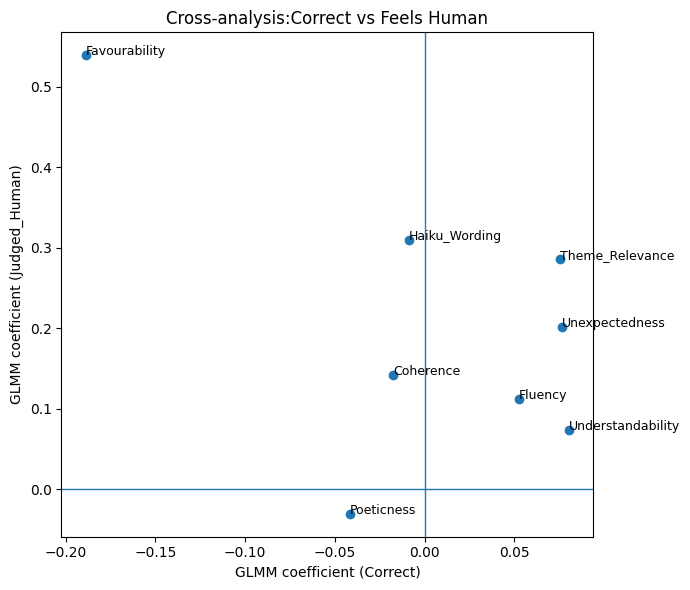

In [70]:
# Scatter: x = effect on correctness, y = effect on judged human
plt.figure(figsize=(7,6))
plt.scatter(cross["coef_correct"], cross["coef_human"])

for _, r in cross.iterrows():
    plt.text(r["coef_correct"], r["coef_human"], r["feature"], fontsize=9)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlabel("GLMM coefficient (Correct)")
plt.ylabel("GLMM coefficient (Judged_Human)")
plt.title("Cross-analysis:Correct vs Feels Human")
plt.tight_layout()
plt.show()

### ***Graphs for the japanese conference slides***

Surface Ratings (Global Pattern) - Estimated marginal means plot with  95% confidence intervals

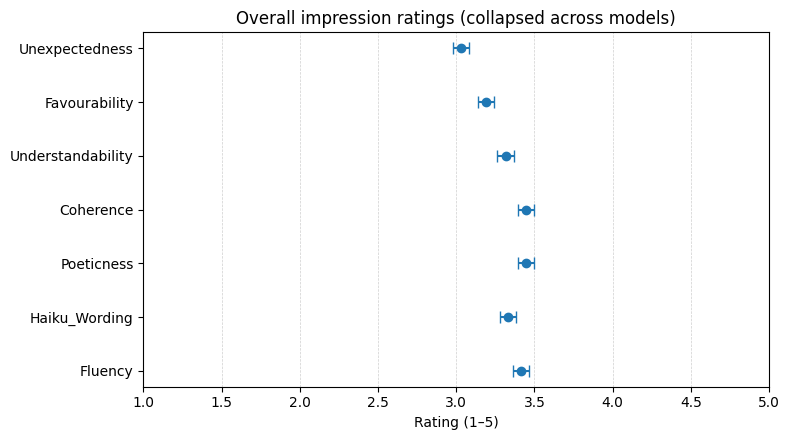

In [71]:
impression_metrics = [
    "Fluency", "Haiku_Wording", "Poeticness", "Coherence",
    "Understandability", "Favourability", "Unexpectedness"
]

# mean and 95% CI per metric (across all haiku + respondents)
summary = []
for m in impression_metrics:
    x = long_all[m].dropna().to_numpy()
    n = len(x)
    mean = x.mean()
    se = x.std(ddof=1) / np.sqrt(n)
    ci = 1.96 * se
    summary.append((m, mean, mean-ci, mean+ci, n))

sum_df = pd.DataFrame(summary, columns=["Metric", "Mean", "CI_low", "CI_high", "N"])

# Plot
fig, ax = plt.subplots(figsize=(8, 4.5))
y = np.arange(len(sum_df))

ax.errorbar(
    sum_df["Mean"], y,
    xerr=[sum_df["Mean"] - sum_df["CI_low"], sum_df["CI_high"] - sum_df["Mean"]],
    fmt="o", capsize=4
)

ax.set_yticks(y)
ax.set_yticklabels(sum_df["Metric"])
ax.set_xlim(1, 5)
ax.set_xlabel("Rating (1–5)")
ax.set_title("Overall impression ratings (collapsed across models)")
ax.grid(axis="x", linestyle="--", linewidth=0.5, alpha=0.6)
plt.tight_layout()
plt.show()

Collapsing across models, we see that ratings cluster in the mid-to-high range, typically between 3 and 3.5 on a 1–5 scale.
Fluency, coherence, and wording are consistently rated positively.
Unexpectedness centers slightly lower but still near the midpoint.

At a surface level, both AI-generated and human-written haiku appear well-formed and readable.

This helps explain why recognition performance is limited: the surface quality distributions overlap substantially.

Ground Truth vs Perceived Authorship - Grouped mean comparison plot with 95% confidence intervals

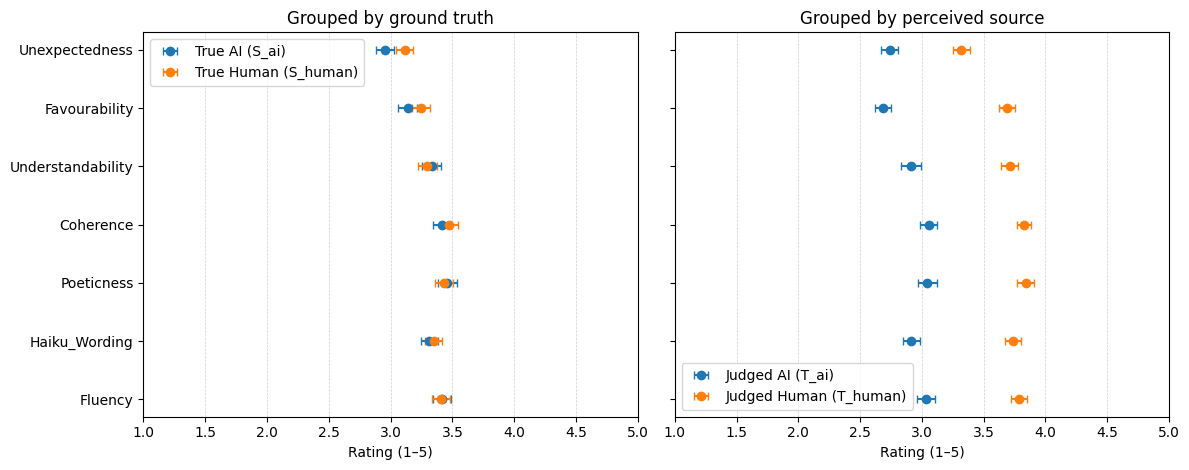

In [36]:
# Build the long S/T-duplicated frame
d = add_ST_set_column(long_all)

# mean ± 95% CI by (Set, Metric)
def summarize_by_set(df, set_name, metrics):
    rows = []
    for m in metrics:
        x = df.loc[df["ST_Set"] == set_name, m].dropna().to_numpy()
        n = len(x)
        mean = x.mean()
        se = x.std(ddof=1) / np.sqrt(n) if n > 1 else np.nan
        ci = 1.96 * se if n > 1 else np.nan
        rows.append((m, mean, mean-ci, mean+ci))
    return pd.DataFrame(rows, columns=["Metric", "Mean", "CI_low", "CI_high"])

# Panel A: Truth-based (S_ai vs S_human)
S_ai = summarize_by_set(d, "S_ai (true AI)", impression_metrics)
S_hu = summarize_by_set(d, "S_human (true Human)", impression_metrics)

# Panel B: Guess-based (T_ai vs T_human)
T_ai = summarize_by_set(d, "T_ai (judged AI)", impression_metrics)
T_hu = summarize_by_set(d, "T_human (judged Human)", impression_metrics)

# Plot: two panels, same y-axis
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)

y = np.arange(len(impression_metrics))

def panel(ax, A, B, labelA, labelB, title):
    ax.errorbar(A["Mean"], y,
                xerr=[A["Mean"]-A["CI_low"], A["CI_high"]-A["Mean"]],
                fmt="o", capsize=3, label=labelA)
    ax.errorbar(B["Mean"], y,
                xerr=[B["Mean"]-B["CI_low"], B["CI_high"]-B["Mean"]],
                fmt="o", capsize=3, label=labelB)

    ax.set_yticks(y)
    ax.set_yticklabels(impression_metrics)
    ax.set_xlim(1, 5)
    ax.set_title(title)
    ax.grid(axis="x", linestyle="--", linewidth=0.5, alpha=0.6)
    ax.legend()

panel(axes[0], S_ai, S_hu, "True AI (S_ai)", "True Human (S_human)", "Grouped by ground truth")
panel(axes[1], T_ai, T_hu, "Judged AI (T_ai)", "Judged Human (T_human)", "Grouped by perceived source")

axes[0].set_xlabel("Rating (1–5)")
axes[1].set_xlabel("Rating (1–5)")
plt.tight_layout()
plt.show()


`Left panel - Grouped by ground truth`

When ratings are grouped by true source, AI and human haiku largely overlap across all dimensions.
The mean differences are small and confidence intervals strongly overlap.
This indicates that surface impression ratings do not meaningfully separate AI from human authorship.

`Right panel - Grouped by perceived source`

However, when grouped by judged source, a clear upward shift appears.
Haiku judged as human are consistently rated higher across favourability, wording, fluency, coherence, and theme relevance.
This shift is systematic and substantial.

Impression ratings track perceived humanness, not ground truth.